In [1]:
import numpy as np

import matplotlib.pyplot as plt

import jax

import jax.numpy as jnp

from jax import jit, vmap

import torch
import torch.nn as nn
import torch.optim as optim

from collections import deque
import random


In [2]:
class Maze:
    def __init__(self, maze, start_position, goal_position):
        self.maze = maze
        self.start_position = start_position
        self.goal_position = goal_position
        self.reset()

    def reset(self):
        self.current_position = self.start_position
        return self.current_position

    def step(self, action):
        next_position = list(self.current_position)

        if action == 0:  # up
            next_position[1] -= 1
        elif action == 1:  # down
            next_position[1] += 1
        elif action == 2:  # left
            next_position[0] -= 1
        elif action == 3:  # right
            next_position[0] += 1

        # within bounds
        if (0 <= next_position[0] < self.maze.shape[1]) and (0 <= next_position[1] < self.maze.shape[0]):
            # not into a wall
            if self.maze[next_position[1], next_position[0]] == 0:
                self.current_position = tuple(next_position)

        done = self.current_position == self.goal_position
        reward = 1 if done else -0.1
        return self.current_position, reward, done

    def render(self):
        maze_copy = self.maze.copy()
        maze_copy[self.current_position[1], self.current_position[0]] = 2
        plt.figure(figsize=(5, 5))
        plt.imshow(maze_copy, cmap='gray')

        plt.text(self.start_position[0], self.start_position[1], 'S', ha='center', va='center', color='red', fontsize=20)
        plt.text(self.goal_position[0], self.goal_position[1], 'G', ha='center', va='center', color='green', fontsize=20)

        plt.show()


In [3]:
class DQN(nn.Module):
    def __init__(self, state_size, action_size):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(state_size, 24)
        self.fc2 = nn.Linear(24, 24)
        self.fc3 = nn.Linear(24, action_size)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)


class DQNAgent:
    def __init__(self, state_size, action_size):
        self.state_size = state_size
        self.action_size = action_size
        self.memory = deque(maxlen=2000)
        self.gamma = 0.95  # discount rate
        self.epsilon = 1.0  # exploration rate
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.995
        self.learning_rate = 0.001
        self.model = DQN(state_size, action_size)
        self.optimizer = optim.Adam(self.model.parameters(), lr=self.learning_rate)
        self.criterion = nn.MSELoss()

    def remember(self, state, action, reward, next_state, done):
        self.memory.append((state, action, reward, next_state, done))

    def act(self, state):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        state = torch.FloatTensor(state).unsqueeze(0)
        act_values = self.model(state)
        return torch.argmax(act_values[0]).item()

    def replay(self, batch_size):
        minibatch = random.sample(self.memory, batch_size)
        for state, action, reward, next_state, done in minibatch:
            target = reward
            if not done:
                next_state = torch.FloatTensor(next_state).unsqueeze(0)
                target = (reward + self.gamma *
                          torch.max(self.model(next_state)[0]).item())
            state = torch.FloatTensor(state).unsqueeze(0)
            target_f = self.model(state)
            target_f[0][action] = target
            self.optimizer.zero_grad()
            loss = self.criterion(target_f, self.model(state))
            loss.backward()
            self.optimizer.step()

        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay


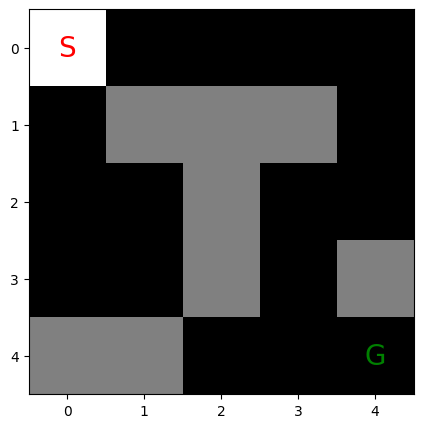

Episode 1/200 finished after 303 timesteps


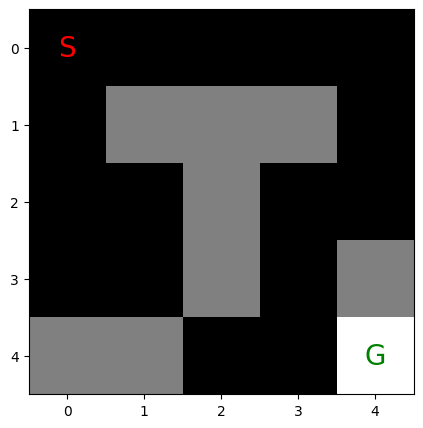

Episode 2/200 finished after 223 timesteps
Episode 3/200 finished after 119 timesteps
Episode 4/200 finished after 114 timesteps
Episode 5/200 finished after 22 timesteps
Episode 6/200 finished after 22 timesteps
Episode 7/200 finished after 46 timesteps
Episode 8/200 finished after 19 timesteps
Episode 9/200 finished after 17 timesteps
Episode 10/200 finished after 16 timesteps
Episode 11/200 finished after 86 timesteps
Episode 12/200 finished after 14 timesteps
Episode 13/200 finished after 13 timesteps
Episode 14/200 finished after 14 timesteps
Episode 15/200 finished after 13 timesteps
Episode 16/200 finished after 12 timesteps
Episode 17/200 finished after 10 timesteps
Episode 18/200 finished after 10 timesteps
Episode 19/200 finished after 10 timesteps
Episode 20/200 finished after 11 timesteps
Episode 21/200 finished after 10 timesteps
Episode 22/200 finished after 10 timesteps
Episode 23/200 finished after 10 timesteps
Episode 24/200 finished after 11 timesteps
Episode 25/200 f

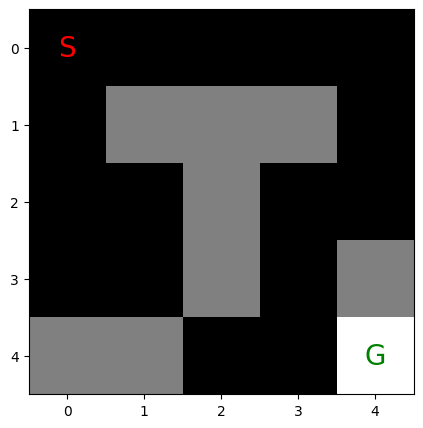

Episode 52/200 finished after 10 timesteps
Episode 53/200 finished after 10 timesteps
Episode 54/200 finished after 10 timesteps
Episode 55/200 finished after 10 timesteps
Episode 56/200 finished after 10 timesteps
Episode 57/200 finished after 11 timesteps
Episode 58/200 finished after 10 timesteps
Episode 59/200 finished after 10 timesteps
Episode 60/200 finished after 11 timesteps
Episode 61/200 finished after 10 timesteps
Episode 62/200 finished after 11 timesteps
Episode 63/200 finished after 10 timesteps
Episode 64/200 finished after 10 timesteps
Episode 65/200 finished after 11 timesteps
Episode 66/200 finished after 10 timesteps
Episode 67/200 finished after 10 timesteps
Episode 68/200 finished after 10 timesteps
Episode 69/200 finished after 10 timesteps
Episode 70/200 finished after 10 timesteps
Episode 71/200 finished after 11 timesteps
Episode 72/200 finished after 10 timesteps
Episode 73/200 finished after 10 timesteps
Episode 74/200 finished after 10 timesteps
Episode 75/

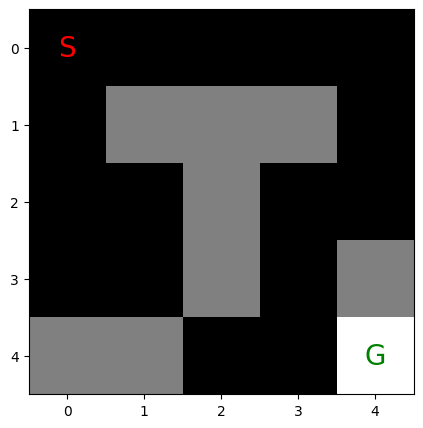

Episode 102/200 finished after 12 timesteps
Episode 103/200 finished after 10 timesteps
Episode 104/200 finished after 10 timesteps
Episode 105/200 finished after 10 timesteps
Episode 106/200 finished after 10 timesteps
Episode 107/200 finished after 10 timesteps
Episode 108/200 finished after 21 timesteps
Episode 109/200 finished after 10 timesteps
Episode 110/200 finished after 12 timesteps
Episode 111/200 finished after 10 timesteps
Episode 112/200 finished after 10 timesteps
Episode 113/200 finished after 10 timesteps
Episode 114/200 finished after 11 timesteps
Episode 115/200 finished after 10 timesteps
Episode 116/200 finished after 10 timesteps
Episode 117/200 finished after 10 timesteps
Episode 118/200 finished after 12 timesteps
Episode 119/200 finished after 10 timesteps
Episode 120/200 finished after 10 timesteps
Episode 121/200 finished after 10 timesteps
Episode 122/200 finished after 10 timesteps
Episode 123/200 finished after 10 timesteps
Episode 124/200 finished after 1

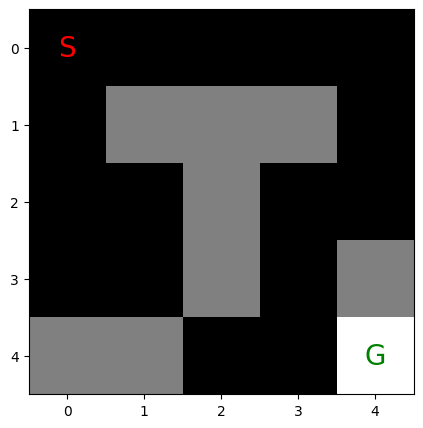

Episode 152/200 finished after 10 timesteps
Episode 153/200 finished after 12 timesteps
Episode 154/200 finished after 10 timesteps
Episode 155/200 finished after 10 timesteps
Episode 156/200 finished after 10 timesteps
Episode 157/200 finished after 10 timesteps
Episode 158/200 finished after 10 timesteps
Episode 159/200 finished after 12 timesteps
Episode 160/200 finished after 12 timesteps
Episode 161/200 finished after 10 timesteps
Episode 162/200 finished after 10 timesteps
Episode 163/200 finished after 10 timesteps
Episode 164/200 finished after 10 timesteps
Episode 165/200 finished after 11 timesteps
Episode 166/200 finished after 12 timesteps
Episode 167/200 finished after 12 timesteps
Episode 168/200 finished after 10 timesteps
Episode 169/200 finished after 10 timesteps
Episode 170/200 finished after 10 timesteps
Episode 171/200 finished after 10 timesteps
Episode 172/200 finished after 10 timesteps
Episode 173/200 finished after 10 timesteps
Episode 174/200 finished after 1

In [4]:
maze_layout = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 1, 1, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 1],
    [1, 1, 0, 0, 0]
])

maze = Maze(maze_layout, (0, 0), (4, 4))
maze.render()

if __name__ == "__main__":
    env = Maze(maze_layout, (0, 0), (4, 4))
    state_size = 2  # x and y position
    action_size = 4  # up, down, left, right
    agent = DQNAgent(state_size, action_size)
    episodes = 200
    batch_size = 32

    for e in range(episodes):
        state = env.reset()
        for time in range(500):
            action = agent.act(state)
            next_state, reward, done = env.step(action)
            agent.remember(state, action, reward, next_state, done)
            state = next_state
            if done:
                print(f"Episode {e+1}/{episodes} finished after {time+1} timesteps")
                break
            if len(agent.memory) > batch_size:
                agent.replay(batch_size)
        if e % 50 == 0:
            env.render()


In [5]:
def test_agent(env, agent, episodes=5):
    success_count = 0
    test_steps = []
    for e in range(episodes):
        state = env.reset()
        steps = 0
        for time in range(100):
            action = agent.act(state)
            next_state, reward, done = env.step(action)
            state = next_state
            steps += 1
            if done:
                test_steps.append(steps)
                success_count += 1
                print(f"Test Episode {e+1}/{episodes} succeeded after {time+1} timesteps")
                break
        # env.render()
    print(f"Agent succeeded in {success_count}/{episodes} test episodes.")
    print("Test Steps:", test_steps)


# Testing the trained agent
test_agent(env, agent)


Test Episode 1/5 succeeded after 11 timesteps
Test Episode 2/5 succeeded after 10 timesteps
Test Episode 3/5 succeeded after 11 timesteps
Test Episode 4/5 succeeded after 10 timesteps
Test Episode 5/5 succeeded after 10 timesteps
Agent succeeded in 5/5 test episodes.
Test Steps: [11, 10, 11, 10, 10]
